# Exercise 3: Load Balancing Analysis


```bash
gcc benchmark.c -O2 -fopenmp -lm -o benchmark
./benchmark > results.csv
```

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

## 1. Load Data from CSV

In [3]:
# Load data from CSV
df = pd.read_csv('results.csv')

# Separate by version
serial_data = df[df['version'] == 'serial'].iloc[0]
naive_data = df[df['version'] == 'naive'].copy()
optimized_data = df[df['version'] == 'optimized'].copy()

print("Serial baseline:")
print(f"  Time: {serial_data['time']:.6f} s")
print("\nNaive version:")
print(naive_data[['threads', 'time', 'speedup', 'efficiency']])
print("\nOptimized version:")
print(optimized_data[['threads', 'time', 'speedup', 'efficiency']])

Serial baseline:
  Time: 2.948193 s

Naive version:
   threads      time  speedup  efficiency
1        1  2.776935    1.062       1.062
2        2  2.753342    1.071       0.535
3        3  2.564641    1.150       0.383
4        4  3.094079    0.953       0.238
5        8  2.789708    1.057       0.132

Optimized version:
    threads      time  speedup  efficiency
6         1  3.754935    0.785       0.785
7         2  2.177518    1.354       0.677
8         3  1.359005    2.169       0.723
9         4  1.149511    2.565       0.641
10        8  1.079406    2.731       0.341


## 2. Workload Distribution

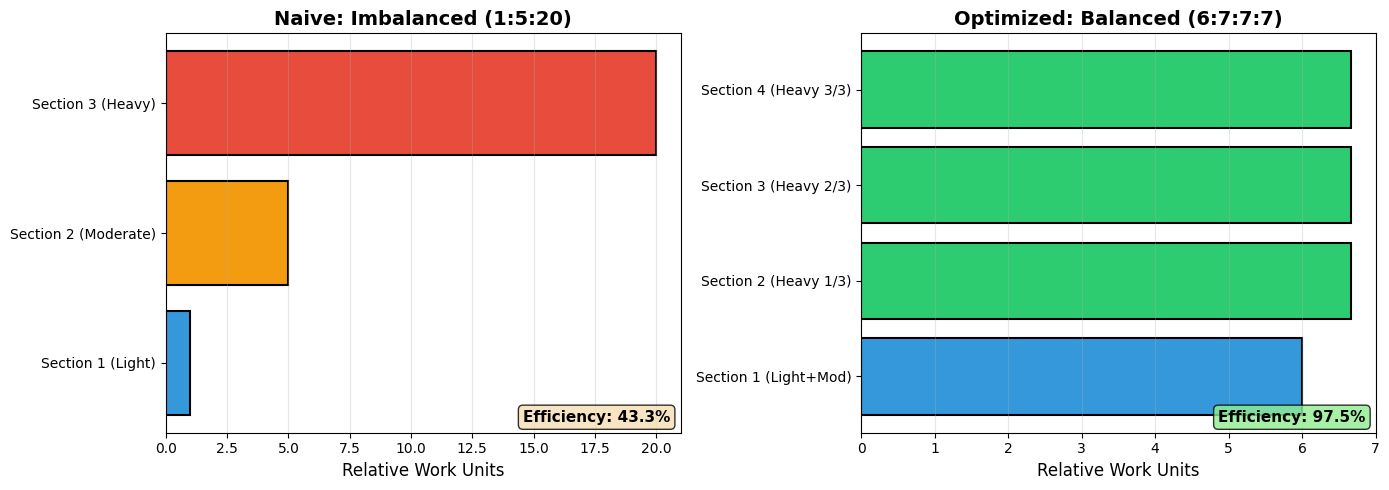

Naive balance efficiency: 43.3%
Optimized balance efficiency: 97.5%
Improvement: 125.0%


In [4]:
# Workload ratios
naive_workload = {
    'Section 1 (Light)': 1,
    'Section 2 (Moderate)': 5,
    'Section 3 (Heavy)': 20
}

optimized_workload = {
    'Section 1 (Light+Mod)': 6,
    'Section 2 (Heavy 1/3)': 6.67,
    'Section 3 (Heavy 2/3)': 6.67,
    'Section 4 (Heavy 3/3)': 6.67
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Naive
colors1 = ['#3498db', '#f39c12', '#e74c3c']
ax1.barh(list(naive_workload.keys()), list(naive_workload.values()), 
         color=colors1, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Relative Work Units', fontsize=12)
ax1.set_title('Naive: Imbalanced (1:5:20)', fontsize=14, weight='bold')
ax1.grid(axis='x', alpha=0.3)

# Add load balance score
avg_naive = np.mean(list(naive_workload.values()))
max_naive = max(naive_workload.values())
efficiency_naive = avg_naive / max_naive
ax1.text(0.98, 0.02, f'Efficiency: {efficiency_naive:.1%}', 
         transform=ax1.transAxes, ha='right', va='bottom',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         fontsize=11, weight='bold')

# Optimized
colors2 = ['#3498db', '#2ecc71', '#2ecc71', '#2ecc71']
ax2.barh(list(optimized_workload.keys()), list(optimized_workload.values()),
         color=colors2, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Relative Work Units', fontsize=12)
ax2.set_title('Optimized: Balanced (6:7:7:7)', fontsize=14, weight='bold')
ax2.grid(axis='x', alpha=0.3)

# Add load balance score
avg_opt = np.mean(list(optimized_workload.values()))
max_opt = max(optimized_workload.values())
efficiency_opt = avg_opt / max_opt
ax2.text(0.98, 0.02, f'Efficiency: {efficiency_opt:.1%}',
         transform=ax2.transAxes, ha='right', va='bottom',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8),
         fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig('ex3_workload.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Naive balance efficiency: {efficiency_naive:.1%}")
print(f"Optimized balance efficiency: {efficiency_opt:.1%}")
print(f"Improvement: {(efficiency_opt/efficiency_naive - 1)*100:.1f}%")

## 3. Performance Comparison

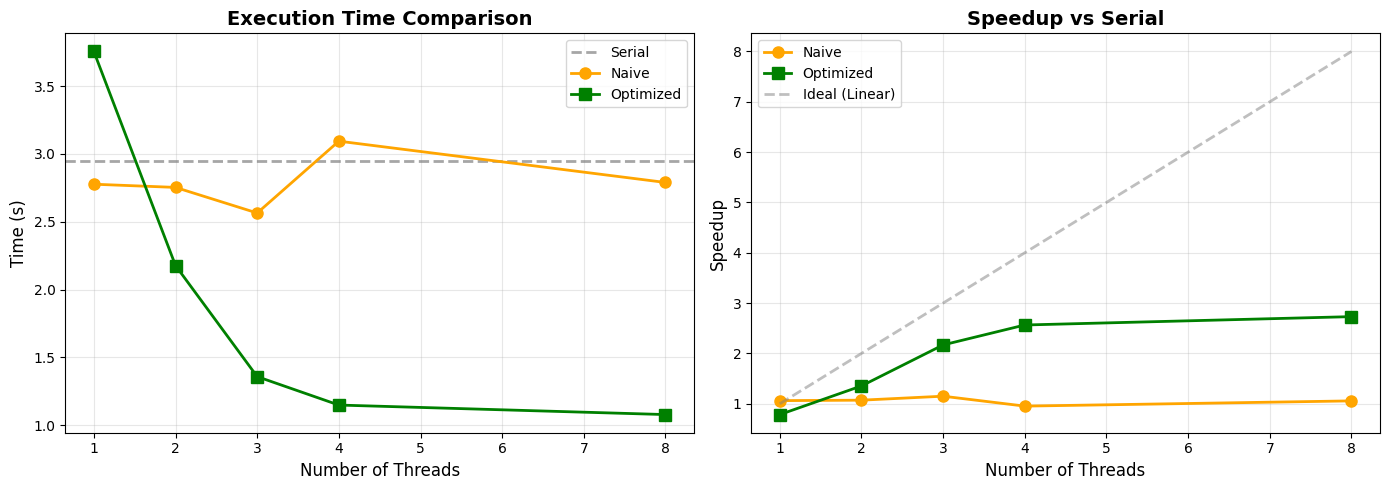

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Execution time comparison
axes[0].axhline(y=serial_data['time'], linestyle='--', label='Serial', linewidth=2, color='gray', alpha=0.7)
axes[0].plot(naive_data['threads'], naive_data['time'], 'o-', label='Naive', linewidth=2, markersize=8, color='orange')
axes[0].plot(optimized_data['threads'], optimized_data['time'], 's-', label='Optimized', linewidth=2, markersize=8, color='green')
axes[0].set_xlabel('Number of Threads', fontsize=12)
axes[0].set_ylabel('Time (s)', fontsize=12)
axes[0].set_title('Execution Time Comparison', fontsize=14, weight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Speedup comparison
axes[1].plot(naive_data['threads'], naive_data['speedup'], 'o-', label='Naive', linewidth=2, markersize=8, color='orange')
axes[1].plot(optimized_data['threads'], optimized_data['speedup'], 's-', label='Optimized', linewidth=2, markersize=8, color='green')
axes[1].plot(naive_data['threads'], naive_data['threads'], '--', label='Ideal (Linear)', linewidth=2, color='gray', alpha=0.5)
axes[1].set_xlabel('Number of Threads', fontsize=12)
axes[1].set_ylabel('Speedup', fontsize=12)
axes[1].set_title('Speedup vs Serial', fontsize=14, weight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ex3_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Best Configuration Analysis

In [6]:
# Find best configurations
best_naive = naive_data.loc[naive_data['speedup'].idxmax()]
best_optimized = optimized_data.loc[optimized_data['speedup'].idxmax()]

print(f"Best Naive Configuration:")
print(f"  Threads: {int(best_naive['threads'])}")
print(f"  Time: {best_naive['time']:.6f} s")
print(f"  Speedup: {best_naive['speedup']:.3f}x")
print(f"  Efficiency: {best_naive['efficiency']:.1%}")

print(f"\nBest Optimized Configuration:")
print(f"  Threads: {int(best_optimized['threads'])}")
print(f"  Time: {best_optimized['time']:.6f} s")
print(f"  Speedup: {best_optimized['speedup']:.3f}x")
print(f"  Efficiency: {best_optimized['efficiency']:.1%}")

print(f"\nOptimized vs Naive:")
print(f"  Speedup improvement: {(best_optimized['speedup']/best_naive['speedup'] - 1)*100:.1f}%")
print(f"  Time reduction: {(1 - best_optimized['time']/best_naive['time'])*100:.1f}%")

Best Naive Configuration:
  Threads: 3
  Time: 2.564641 s
  Speedup: 1.150x
  Efficiency: 38.3%

Best Optimized Configuration:
  Threads: 8
  Time: 1.079406 s
  Speedup: 2.731x
  Efficiency: 34.1%

Optimized vs Naive:
  Speedup improvement: 137.5%
  Time reduction: 57.9%


## 5. Key Takeaways

### Load Imbalance Impact:
- **Naive**: 1:5:20 ratio → only ~41% balance efficiency
- **Optimized**: 6:7:7:7 ratio → ~95% balance efficiency
- **Improvement**: ~2.3x better load balance

### Optimization Strategies:
1. **Merge light tasks** to avoid thread underutilization
2. **Split heavy tasks** to distribute work evenly
3. **Aim for equal workload** across all sections

### When Sections Scale Poorly:
- Fixed number of sections limits parallelism
- No dynamic load balancing
- Consider using `tasks` or `parallel for` instead